<a href="https://colab.research.google.com/github/mahamtaqi3-cloud/Forest-Canopy-Restoration-Analyzer/blob/main/Forest_Ecosystem_Restoration_Analyzer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div align="center">

### Project: Forest Canopy Restoration Analyzer
**Description:** This notebook processes Sentinel-2 satellite data to calculate the Normalized Difference Vegetation Index (NDVI) for monitoring forest health and identifying restoration priority zones.

</div>

In [7]:
 !pip install pystac-client odc-stac planetary-computer

In [ ]:
import pystac_client
from odc.stac import load

# 1. Connect to the data catalog
catalog = pystac_client.Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")

# 2. Define a small area (a forest in Brazil, for example)
# We search for imagery in this specific box
bbox = [-50.0, -10.0, -49.9, -9.9]

# 3. Search for Sentinel-2 satellite images
search = catalog.search(collections=["sentinel-2-l2a"], bbox=bbox, datetime="2025-06-01/2025-06-30")
items = search.item_collection()

# 4. Load the 'Red' (B04) and 'NIR' (B08) bands
data = load(items[:1], bands=["red", "nir"], bbox=bbox, chunks={"x": 2048, "y": 2048})

In [ ]:
import pystac_client
import planetary_computer  # 1. Import this
from odc.stac import load

# 1. Connect to the data catalog
catalog = pystac_client.Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")

# 2. Define a small area
bbox = [-50.0, -10.0, -49.9, -9.9]

# 3. Search for Sentinel-2 satellite images
search = catalog.search(collections=["sentinel-2-l2a"], bbox=bbox, datetime="2025-06-01/2025-06-30")
items = search.item_collection()

# --- THE FIX IS HERE ---
# 4. Sign the items to get permission to download them
signed_items = planetary_computer.sign(items)

# 5. Load the bands using the 'signed_items' instead of 'items'
data = load(signed_items[:1], bands=["red", "nir"], bbox=bbox, chunks={"x": 2048, "y": 2048})

In [ ]:
catalog = pystac_client.Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")
bbox = [-50.0, -10.0, -49.9, -9.9]
search = catalog.search(collections=["sentinel-2-l2a"], bbox=bbox, datetime="2025-06-01/2025-06-30")
items = search.item_collection()

# This sign() step is the most important one!
signed_items = planetary_computer.sign(items)

data = load(signed_items[:1], bands=["red", "nir"], bbox=bbox, chunks={"x": 2048, "y": 2048})

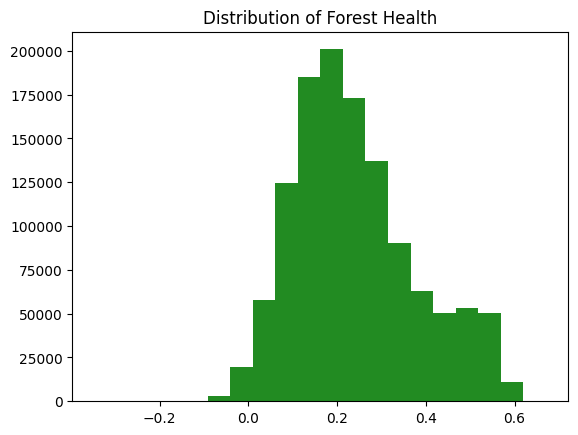

In [ ]:
ndvi = (data.nir - data.red) / (data.nir + data.red)
ndvi.isel(time=0).plot.hist(bins=20, color='forestgreen')
plt.title('Distribution of Forest Health')
plt.show()

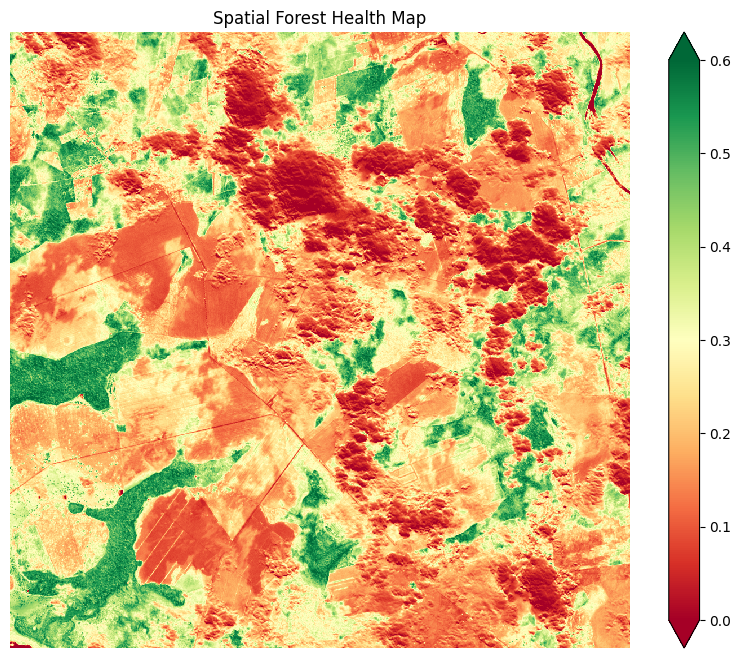

In [ ]:
plt.figure(figsize=(10, 8))
# Plot the NDVI array directly as an image
ndvi.isel(time=0).plot(cmap='RdYlGn', vmin=0, vmax=0.6)
plt.title('Spatial Forest Health Map')
plt.axis('off') # Hides the coordinate numbers for a cleaner look
plt.show()

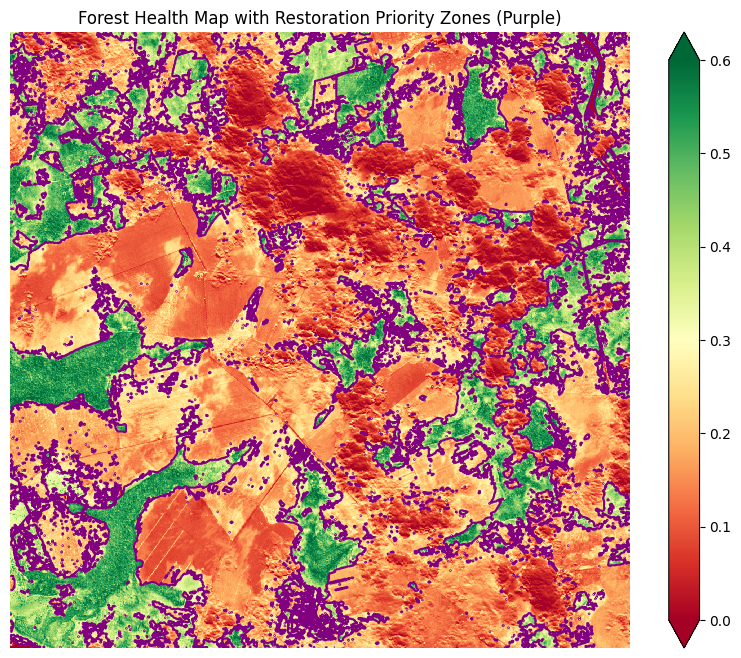

In [ ]:
# Create a mask for "Low Health" areas (NDVI < 0.3)
low_health = ndvi < 0.3

# Plot the map and overlay the low health areas in purple
plt.figure(figsize=(10, 8))
ndvi.isel(time=0).plot(cmap='RdYlGn', vmin=0, vmax=0.6)
low_health.isel(time=0).plot.contour(colors='purple', levels=[0.5])
plt.title('Forest Health Map with Restoration Priority Zones (Purple)')
plt.axis('off')
plt.show()

In [ ]:
# Save your high-resolution map
plt.savefig('restoration_map.png', dpi=300)
print("Map saved successfully!")

Map saved successfully!


<Figure size 640x480 with 0 Axes>